In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "text.color": "black",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.figsize": (8, 4.8),
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
sns.set_theme(style="whitegrid", context="paper")
MODEL_LABELS = {"fp32": "FP32", "fp16": "FP16"}
PALETTE = {"FP32": "#1f77b4", "FP16": "#d62728"}
OUT_DIR = Path("analysis_outputs")
OUT_DIR.mkdir(exist_ok=True)

In [3]:
RESULT_JSON = Path("yolo11_fp32_fp16_eval_results.json")
with RESULT_JSON.open("r", encoding="utf-8") as f:
    result = json.load(f)

meta = result["meta"]
models = result["models"]
print(f"images        : {meta['evaluated_images']}")
print(f"image_dir     : {meta['image_dir']}")
print(f"annotations   : {meta['annotations']}")
print(f"input_size    : {meta['input_size']}")
print(f"batch_size    : {meta['batch_size']}")

images        : 5000
image_dir     : /home/nvidia/workspace/val2017
annotations   : /home/nvidia/workspace/annotations_trainval2017/annotations/instances_val2017.json
input_size    : 640
batch_size    : 1


In [4]:
summary_rows = []
for precision, data in models.items():
    coco = data["coco_bbox"]
    f1 = data["custom_f1"]
    speed = data["speed"]
    summary_rows.append({
        "precision": MODEL_LABELS[precision],
        "mAP50:95": coco["AP@[IoU=0.50:0.95]"],
        "AP50": coco["AP50"],
        "AP75": coco["AP75"],
        "AP_small": coco["AP_small"],
        "AP_medium": coco["AP_medium"],
        "AP_large": coco["AP_large"],
        "Precision": f1["precision"],
        "Recall": f1["recall"],
        "F1": f1["f1"],
        "img/s": speed["images_per_sec"],
        "ms/image": speed["avg_inference_ms_per_image"],
        "detections": speed["detections"],
    })

summary_df = pd.DataFrame(summary_rows).set_index("precision")
summary_df.round(4)

,mAP50:95,AP50,AP75,AP_small,AP_medium,AP_large,Precision,Recall,F1,img/s,ms/image,detections
precision,,,,,,,,,,,,
FP32,0.4527,0.5846,0.4948,0.2565,0.5049,0.6376,0.7164,0.6483,0.6807,61.1400,16.3559,32878
FP16,0.4447,0.5722,0.4863,0.2409,0.4970,0.6356,0.6605,0.6479,0.6542,101.0272,9.8983,35643


In [5]:
iou_rows = []
for precision, data in models.items():
    ap_by_iou = data["coco_bbox"]["AP_by_IoU"]
    f1_by_iou = data["custom_f1_by_iou"]
    for iou, ap in ap_by_iou.items():
        f1 = f1_by_iou[iou]
        iou_rows.append({
            "precision": MODEL_LABELS[precision],
            "IoU": float(iou),
            "AP": ap,
            "Precision": f1["precision"],
            "Recall": f1["recall"],
            "F1": f1["f1"],
        })

iou_df = pd.DataFrame(iou_rows)
delta_df = (
    iou_df.pivot(index="IoU", columns="precision", values=["AP", "F1"])
    .sort_index()
)
delta_df[("AP", "FP16-FP32")] = delta_df[("AP", "FP16")] - delta_df[("AP", "FP32")]
delta_df[("F1", "FP16-FP32")] = delta_df[("F1", "FP16")] - delta_df[("F1", "FP32")]
delta_df.round(4)

AP              F1                AP        F1
precision    FP16    FP32    FP16    FP32 FP16-FP32 FP16-FP32
IoU                                                          
0.50       0.5722  0.5846  0.6542  0.6807   -0.0125   -0.0265
0.55       0.5611  0.5733  0.6444  0.6705   -0.0122   -0.0261
0.60       0.5485  0.5600  0.6320  0.6574   -0.0114   -0.0254
0.65       0.5340  0.5446  0.6163  0.6409   -0.0106   -0.0247
0.70       0.5146  0.5244  0.5949  0.6190   -0.0098   -0.0241
0.75       0.4863  0.4948  0.5653  0.5878   -0.0085   -0.0225
0.80       0.4455  0.4528  0.5215  0.5416   -0.0073   -0.0201
0.85       0.3840  0.3884  0.4530  0.4706   -0.0044   -0.0176
0.90       0.2844  0.2864  0.3481  0.3607   -0.0020   -0.0126
0.95       0.1164  0.1176  0.1684  0.1749   -0.0013   -0.0066

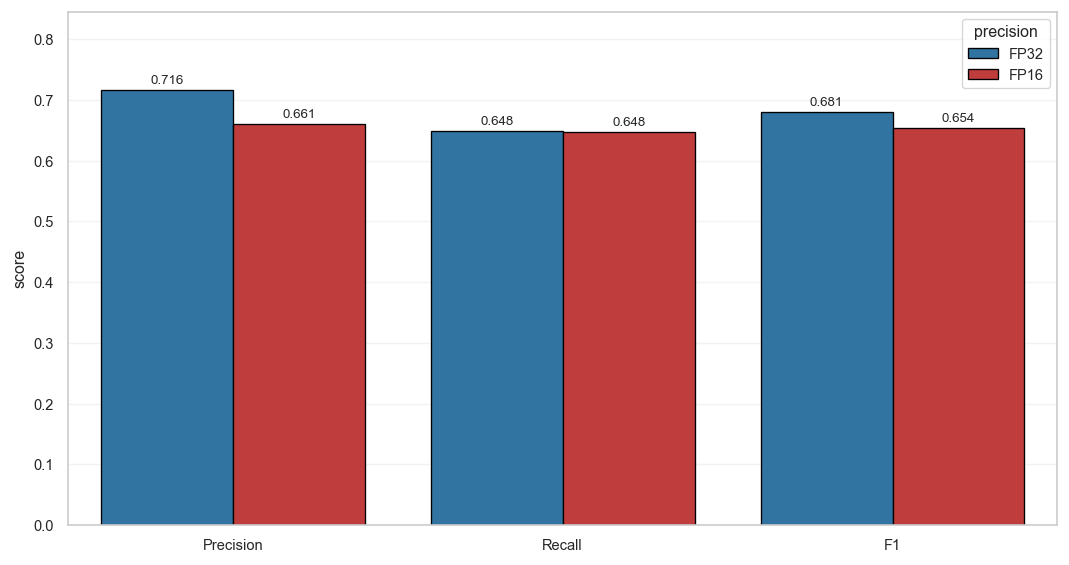

In [6]:
metric_df = (
    summary_df.reset_index()
    .melt(
        id_vars="precision",
        value_vars=["Precision", "Recall", "F1"],
        var_name="metric",
        value_name="value",
    )
)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(data=metric_df, x="metric", y="value", hue="precision", palette=PALETTE, ax=ax, edgecolor='black')
ax.set_ylim(0, max(metric_df["value"]) * 1.18)
ax.set_xlabel("")
ax.set_ylabel("score")
#ax.set_title("FP32 vs FP16 Accuracy Metrics")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)

ax.legend(title="precision")
fig.tight_layout()
fig.savefig(OUT_DIR / "accuracy_metrics_bar.png")
plt.show()

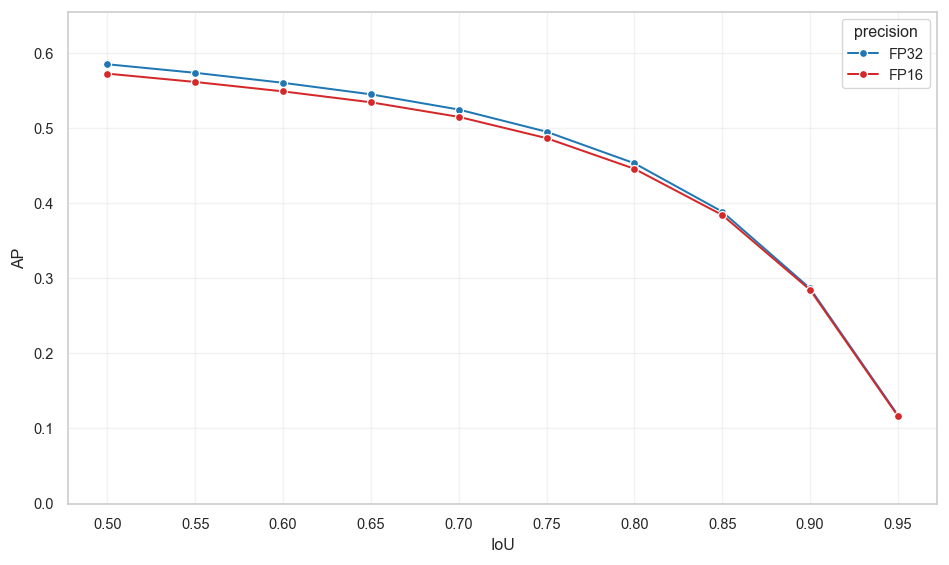

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.lineplot(data=iou_df, x="IoU", y="AP", hue="precision", marker="o", palette=PALETTE, ax=ax)
#ax.set_title("COCO AP by IoU Threshold")
ax.set_ylabel("AP")
ax.set_ylim(0, iou_df["AP"].max() * 1.12)
ax.set_xticks(sorted(iou_df["IoU"].unique()))
#ax.legend(title="Precision")
fig.tight_layout()
fig.savefig(OUT_DIR / "ap_by_iou.png")
plt.show()

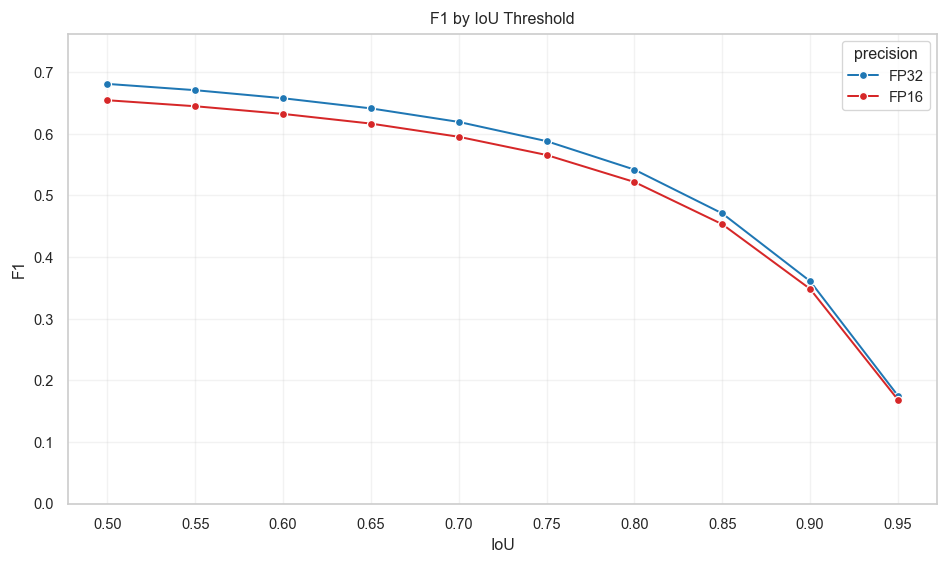

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.lineplot(data=iou_df, x="IoU", y="F1", hue="precision", marker="o", palette=PALETTE, ax=ax)
ax.set_title("F1 by IoU Threshold")
ax.set_ylabel("F1")
ax.set_ylim(0, iou_df["F1"].max() * 1.12)
ax.set_xticks(sorted(iou_df["IoU"].unique()))
ax.legend(title="precision")
fig.tight_layout()
fig.savefig(OUT_DIR / "f1_by_iou.png")
plt.show()

/tmp/ipykernel_394692/6526317.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f"{x:.2f}" for x in delta_plot_df["IoU"]], rotation=0)


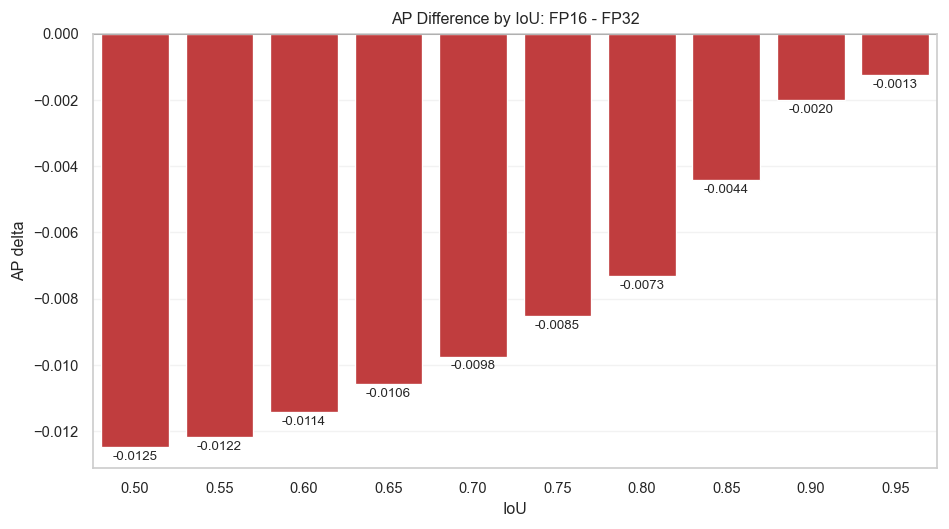

In [9]:
delta_plot_df = delta_df.reset_index()
delta_plot_df.columns = ["_".join([str(x) for x in col if x]) if isinstance(col, tuple) else col for col in delta_plot_df.columns]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axhline(0, color="black", linewidth=1)
sns.barplot(data=delta_plot_df, x="IoU", y="AP_FP16-FP32", color="#d62728", ax=ax)
ax.set_title("AP Difference by IoU: FP16 - FP32")
ax.set_xlabel("IoU")
ax.set_ylabel("AP delta")
ax.set_xticklabels([f"{x:.2f}" for x in delta_plot_df["IoU"]], rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=2, fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / "ap_delta_by_iou.png")
plt.show()

/tmp/ipykernel_394692/3094530401.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="precision", y="value", palette=PALETTE, ax=ax)
/tmp/ipykernel_394692/3094530401.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="precision", y="value", palette=PALETTE, ax=ax)


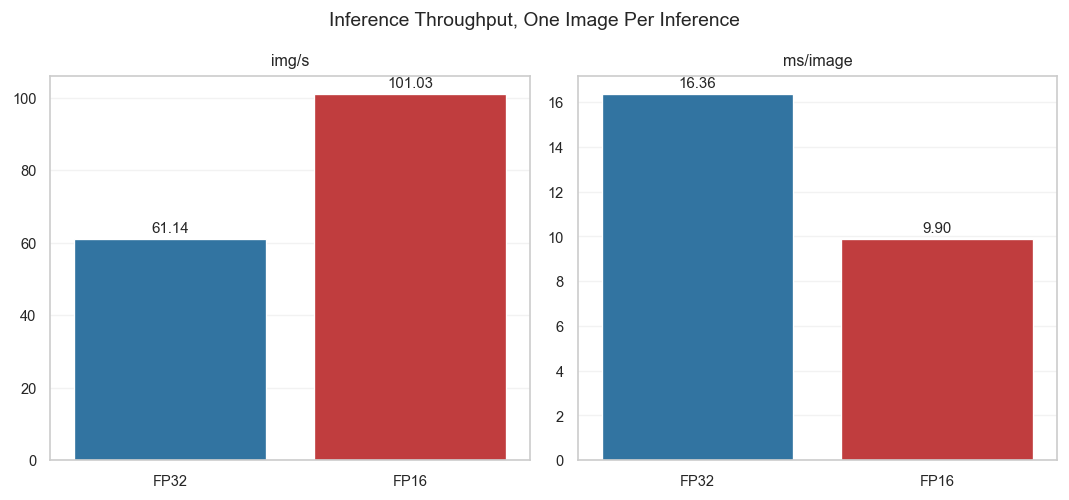

In [10]:
speed_df = summary_df.reset_index().melt(
    id_vars="precision",
    value_vars=["img/s", "ms/image"],
    var_name="metric",
    value_name="value",
)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, metric in zip(axes, ["img/s", "ms/image"]):
    sub = speed_df[speed_df["metric"] == metric]
    sns.barplot(data=sub, x="precision", y="value", palette=PALETTE, ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=2, fontsize=9)
fig.suptitle("Inference Throughput, One Image Per Inference")
fig.tight_layout()
fig.savefig(OUT_DIR / "speed_comparison.png")
plt.show()

In [11]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

DET_FILES = {
    "FP32": Path("yolo11_fp32_fp16_eval_results_fp32_detections.json"),
    "FP16": Path("yolo11_fp32_fp16_eval_results_fp16_detections.json"),
}
missing = [str(path) for path in DET_FILES.values() if not path.exists()]
if missing:
    message = "PR curve requires detection JSON files. Run: python compare_yolo11_fp32_fp16_eval.py --save-detections"
    raise FileNotFoundError(message + "\n" + "\n".join(missing))

In [12]:
def build_coco_evaluator(annotation_path, detections_path, image_ids):
    coco_gt = COCO(str(annotation_path))
    with open(detections_path, "r", encoding="utf-8") as f:
        detections = json.load(f)
    coco_dt = coco_gt.loadRes(detections)
    evaluator = COCOeval(coco_gt, coco_dt, "bbox")
    evaluator.params.imgIds = image_ids
    evaluator.evaluate()
    evaluator.accumulate()
    return evaluator


def mean_pr_curve(evaluator, iou_threshold=None):
    precision = evaluator.eval["precision"]
    # precision: [IoU, recall, category, area, maxDets]
    if iou_threshold is None:
        values = precision[:, :, :, 0, 2]
        values = np.where(values < 0, np.nan, values)
        pr = np.nanmean(values, axis=(0, 2))
    else:
        idx = int(np.argmin(np.abs(evaluator.params.iouThrs - iou_threshold)))
        values = precision[idx, :, :, 0, 2]
        values = np.where(values < 0, np.nan, values)
        pr = np.nanmean(values, axis=1)
    return evaluator.params.recThrs, pr

annotation_path = Path(meta["annotations"])
image_ids = sorted(int(Path(p).stem) for p in Path(meta["image_dir"]).glob("*.jpg"))
evaluators = {
    precision: build_coco_evaluator(annotation_path, det_path, image_ids)
    for precision, det_path in DET_FILES.items()
}
print("COCO PR evaluators ready:", list(evaluators))

loading annotations into memory...
Done (t=0.59s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.25s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=15.59s).
Accumulating evaluation results...
DONE (t=2.58s).
loading annotations into memory...
Done (t=0.41s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.92s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=16.60s).
Accumulating evaluation results...
DONE (t=2.65s).
COCO PR evaluators ready: ['FP32', 'FP16']


In [13]:
pr_rows = []
for precision, evaluator in evaluators.items():
    for label, iou_threshold in [("IoU=0.50", 0.50), ("IoU=0.75", 0.75), ("IoU=0.50:0.95", None)]:
        recall, pr = mean_pr_curve(evaluator, iou_threshold)
        for r, p in zip(recall, pr):
            pr_rows.append({
                "precision": precision,
                "curve": label,
                "recall": float(r),
                "precision_value": float(p),
            })

pr_df = pd.DataFrame(pr_rows)
pr_df.head()

,precision,curve,recall,precision_value
0,FP32,IoU=0.50,0.00,0.987500
1,FP32,IoU=0.50,0.01,0.981718
2,FP32,IoU=0.50,0.02,0.978537
3,FP32,IoU=0.50,0.03,0.974073
4,FP32,IoU=0.50,0.04,0.971436


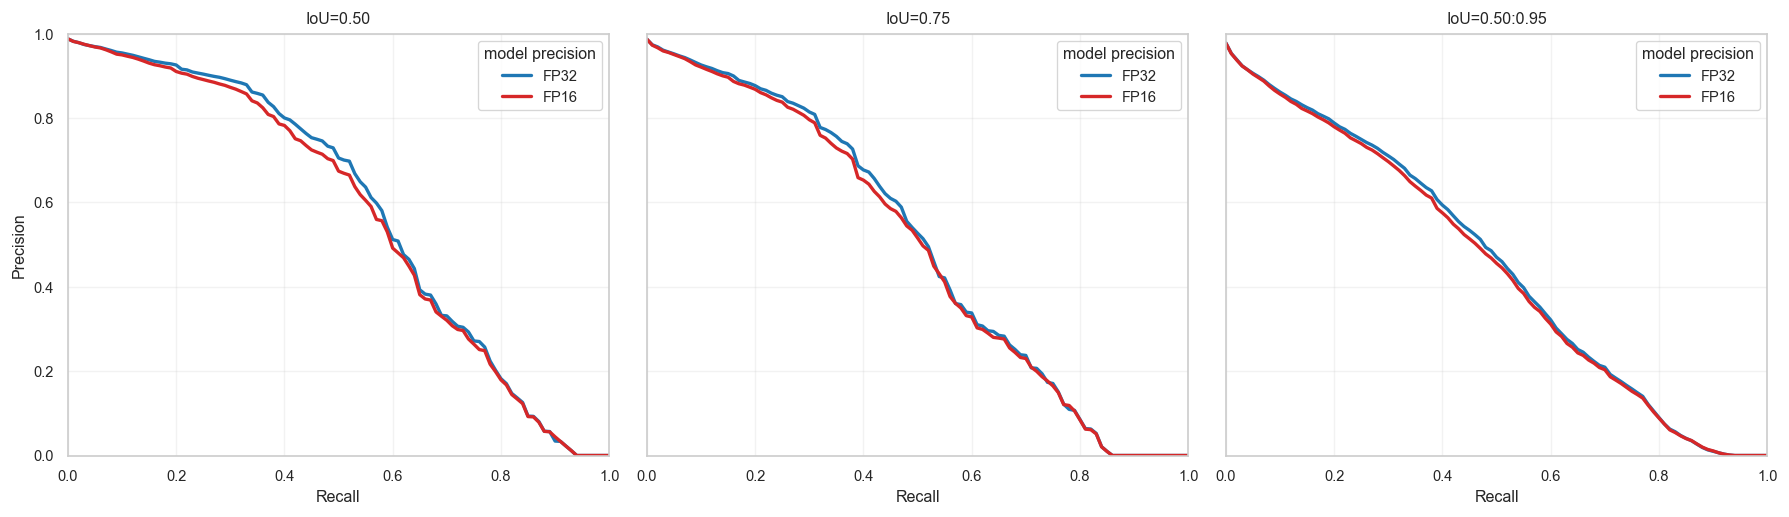

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharex=True, sharey=True)
for ax, curve_name in zip(axes, ["IoU=0.50", "IoU=0.75", "IoU=0.50:0.95"]):
    sub = pr_df[pr_df["curve"] == curve_name]
    sns.lineplot(
        data=sub,
        x="recall",
        y="precision_value",
        hue="precision",
        palette=PALETTE,
        linewidth=2.0,
        ax=ax,
    )
    ax.set_title(curve_name)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(title="model precision")
#fig.suptitle("COCO PR Curves by Model Precision")
fig.tight_layout()
fig.savefig(OUT_DIR / "pr_curves_by_precision.png")
plt.show()

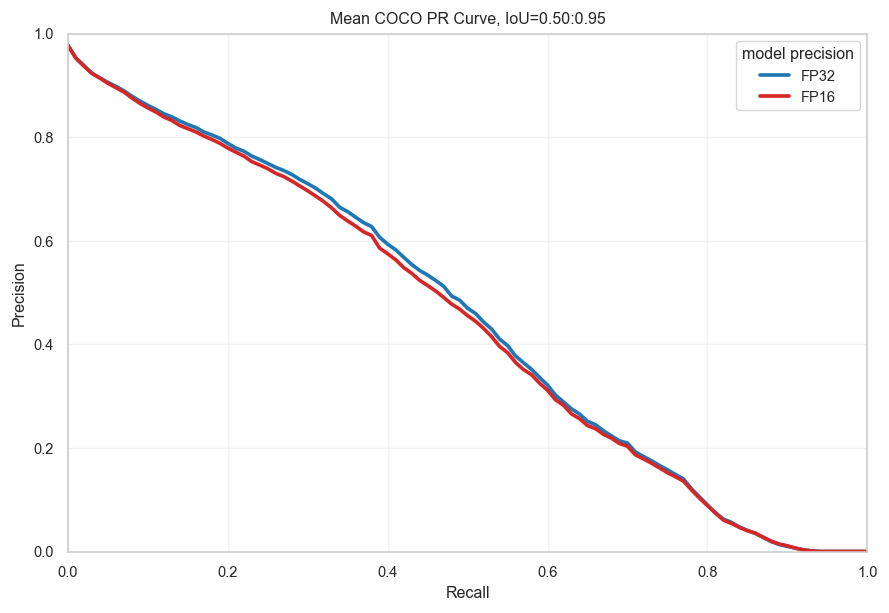

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 5.2))
sub = pr_df[pr_df["curve"] == "IoU=0.50:0.95"]
sns.lineplot(
    data=sub,
    x="recall",
    y="precision_value",
    hue="precision",
    palette=PALETTE,
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Mean COCO PR Curve, IoU=0.50:0.95")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(title="model precision")
fig.tight_layout()
fig.savefig(OUT_DIR / "pr_curve_mean_iou_by_precision.png")
plt.show()

In [16]:
def bbox_iou_xywh(box_a, box_b):
    ax1, ay1, aw, ah = box_a
    bx1, by1, bw, bh = box_b
    ax2, ay2 = ax1 + aw, ay1 + ah
    bx2, by2 = bx1 + bw, by1 + bh
    inter_w = max(0.0, min(ax2, bx2) - max(ax1, bx1))
    inter_h = max(0.0, min(ay2, by2) - max(ay1, by1))
    inter = inter_w * inter_h
    union = aw * ah + bw * bh - inter
    return inter / union if union > 0 else 0.0


def load_gt_by_image_category(annotation_path, image_ids):
    with open(annotation_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    selected = set(image_ids)
    gt_by_key = {}
    for ann in data["annotations"]:
        if ann["image_id"] not in selected or ann.get("iscrowd", 0):
            continue
        key = (ann["image_id"], ann["category_id"])
        gt_by_key.setdefault(key, []).append({"bbox": ann["bbox"], "matched": False})
    return gt_by_key


def f1_at_confidence(gt_template, detections, confidence_threshold, iou_threshold=0.50):
    gt_by_key = {key: [{"bbox": item["bbox"], "matched": False} for item in items]
                 for key, items in gt_template.items()}
    det_by_key = {}
    for det in detections:
        if det["score"] < confidence_threshold:
            continue
        key = (det["image_id"], det["category_id"])
        det_by_key.setdefault(key, []).append(det)

    tp = 0
    fp = 0
    for key, dets in det_by_key.items():
        gts = gt_by_key.get(key, [])
        for det in sorted(dets, key=lambda item: item["score"], reverse=True):
            best_iou = 0.0
            best_gt = None
            for gt in gts:
                if gt["matched"]:
                    continue
                iou = bbox_iou_xywh(det["bbox"], gt["bbox"])
                if iou > best_iou:
                    best_iou = iou
                    best_gt = gt
            if best_gt is not None and best_iou >= iou_threshold:
                best_gt["matched"] = True
                tp += 1
            else:
                fp += 1

    fn = sum(1 for items in gt_by_key.values() for item in items if not item["matched"])
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return precision, recall, f1, tp, fp, fn

In [17]:
CONFIDENCE_THRESHOLDS = np.round(np.arange(0.01, 1.00, 0.01), 2)
F1_IOU_THRESHOLD = 0.50

annotation_path = Path(meta["annotations"])
image_ids = sorted(int(Path(p).stem) for p in Path(meta["image_dir"]).glob("*.jpg"))
gt_template = load_gt_by_image_category(annotation_path, image_ids)

confidence_rows = []
for precision_name, det_path in DET_FILES.items():
    with det_path.open("r", encoding="utf-8") as f:
        detections = json.load(f)
    for conf in CONFIDENCE_THRESHOLDS:
        p, r, f1, tp, fp, fn = f1_at_confidence(
            gt_template, detections, float(conf), iou_threshold=F1_IOU_THRESHOLD
        )
        confidence_rows.append({
            "precision": precision_name,
            "confidence": float(conf),
            "Precision": p,
            "Recall": r,
            "F1": f1,
            "TP": tp,
            "FP": fp,
            "FN": fn,
        })

confidence_df = pd.DataFrame(confidence_rows)
best_f1_df = (
    confidence_df.sort_values("F1", ascending=False)
    .groupby("precision", as_index=False)
    .first()
    .sort_values("precision")
)
best_f1_df[["precision", "confidence", "Precision", "Recall", "F1", "TP", "FP", "FN"]].round(4)

,precision,confidence,Precision,Recall,F1,TP,FP,FN
0,FP16,0.32,0.7213,0.6144,0.6636,22323,8625,14012
1,FP32,0.30,0.7580,0.6244,0.6847,22686,7243,13649


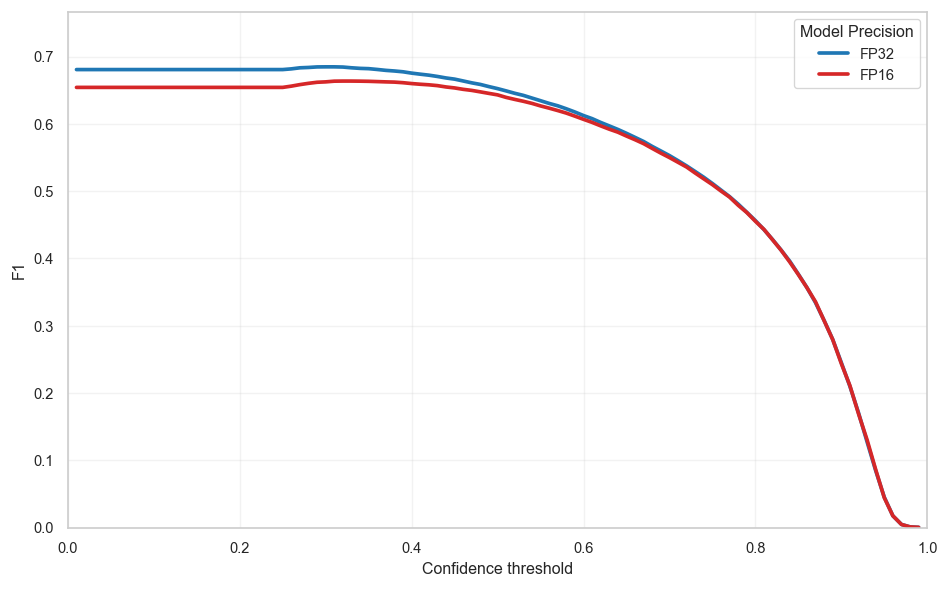

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(
    data=confidence_df,
    x="confidence",
    y="F1",
    hue="precision",
    palette=PALETTE,
    linewidth=2.2,
    ax=ax,
)
# for _, row in best_f1_df.iterrows():
#     ax.scatter(row["confidence"], row["F1"], color=PALETTE[row["precision"]], s=48, zorder=5)
#     ax.annotate(
#         f"{row['precision']} best\nconf={row['confidence']:.2f}, F1={row['F1']:.3f}",
#         xy=(row["confidence"], row["F1"]),
#         xytext=(8, -18),
#         textcoords="offset points",
#         fontsize=8,
#     )
#ax.set_title(f"F1 by Confidence Threshold, IoU={F1_IOU_THRESHOLD:.2f}")
ax.set_xlabel("Confidence threshold")
ax.set_ylabel("F1")
ax.set_xlim(0, 1)
ax.set_ylim(0, confidence_df["F1"].max() * 1.12)
ax.legend(title="Model Precision")
fig.tight_layout()
fig.savefig(OUT_DIR / "f1_by_confidence.png")
plt.show()

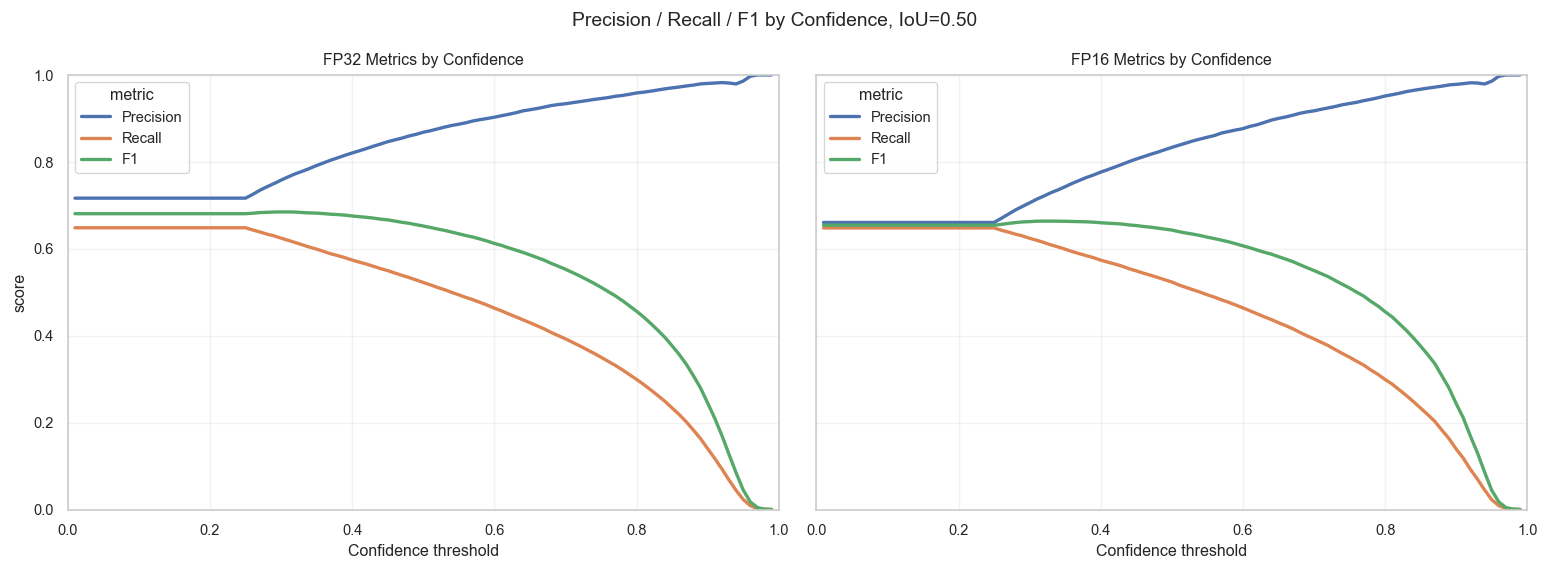

In [19]:
pr_conf_df = confidence_df.melt(
    id_vars=["precision", "confidence"],
    value_vars=["Precision", "Recall", "F1"],
    var_name="metric",
    value_name="score",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, precision_name in zip(axes, ["FP32", "FP16"]):
    sub = pr_conf_df[pr_conf_df["precision"] == precision_name]
    sns.lineplot(
        data=sub,
        x="confidence",
        y="score",
        hue="metric",
        linewidth=2.0,
        ax=ax,
    )
    ax.set_title(f"{precision_name} Metrics by Confidence")
    ax.set_xlabel("Confidence threshold")
    ax.set_ylabel("score")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(title="metric")
fig.suptitle(f"Precision / Recall / F1 by Confidence, IoU={F1_IOU_THRESHOLD:.2f}")
fig.tight_layout()
fig.savefig(OUT_DIR / "precision_recall_f1_by_confidence.png")
plt.show()

In [20]:
ap_loss = summary_df.loc["FP16", "mAP50:95"] - summary_df.loc["FP32", "mAP50:95"]
f1_loss = summary_df.loc["FP16", "F1"] - summary_df.loc["FP32", "F1"]
speedup = summary_df.loc["FP16", "img/s"] / summary_df.loc["FP32", "img/s"]

print(f"FP16 mAP50:95 delta : {ap_loss:+.4f}")
print(f"FP16 F1 delta       : {f1_loss:+.4f}")
print(f"FP16 speedup        : {speedup:.2f}x")
print(f"figures saved to    : {OUT_DIR.resolve()}")

FP16 mAP50:95 delta : -0.0080
FP16 F1 delta       : -0.0265
FP16 speedup        : 1.65x
figures saved to    : /home/nvidia/workspace/deepstream_yolo/analysis_outputs
